데이터 로드 완료


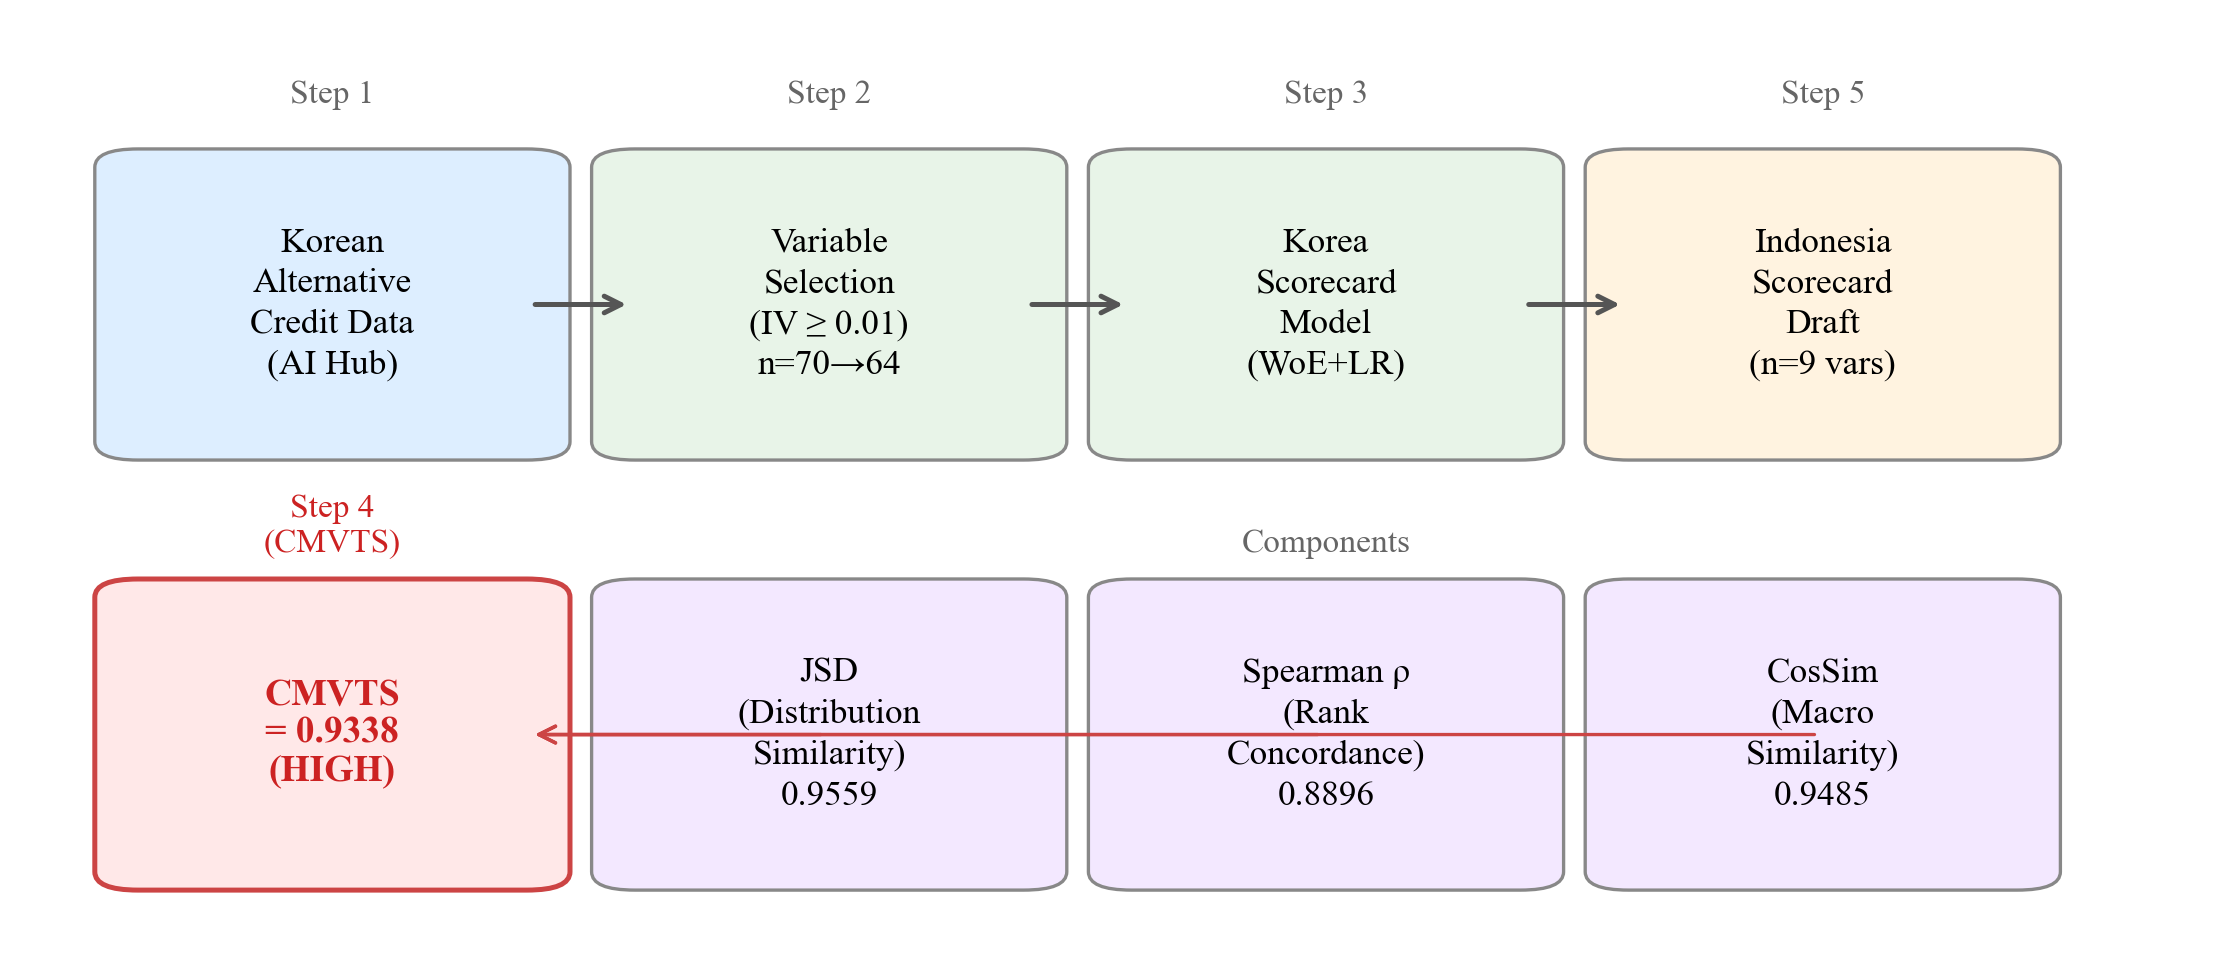

Figure 1 저장 완료


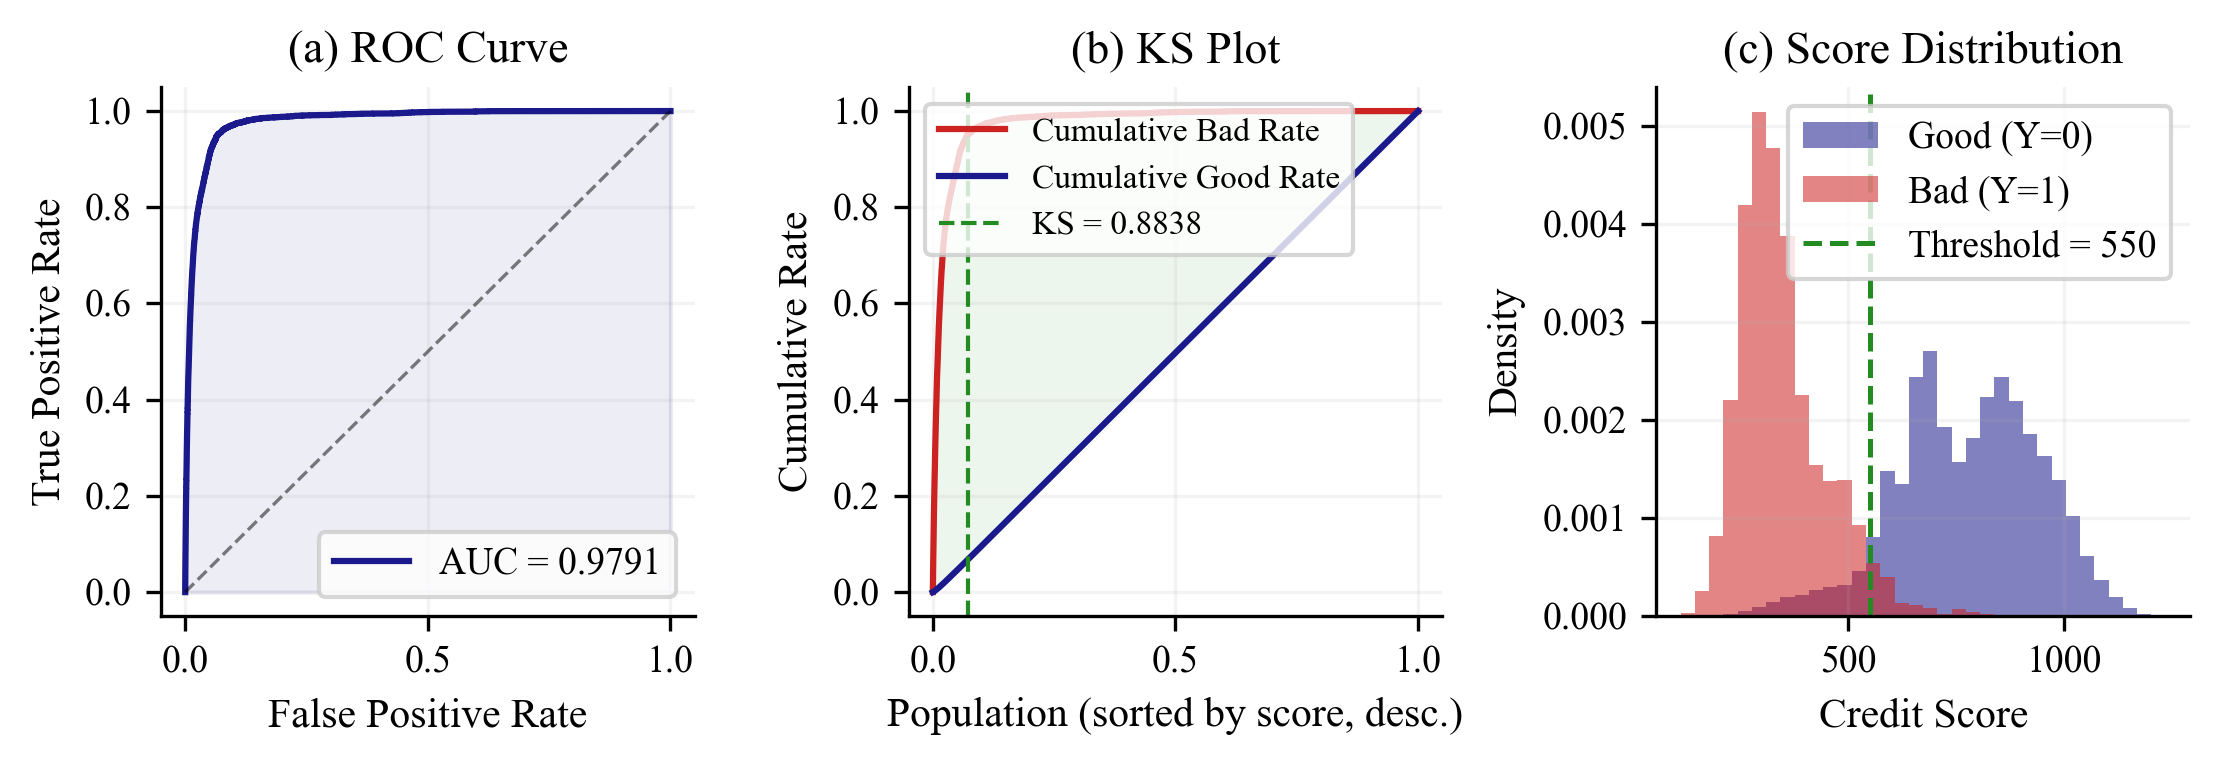

Figure 2 저장 완료


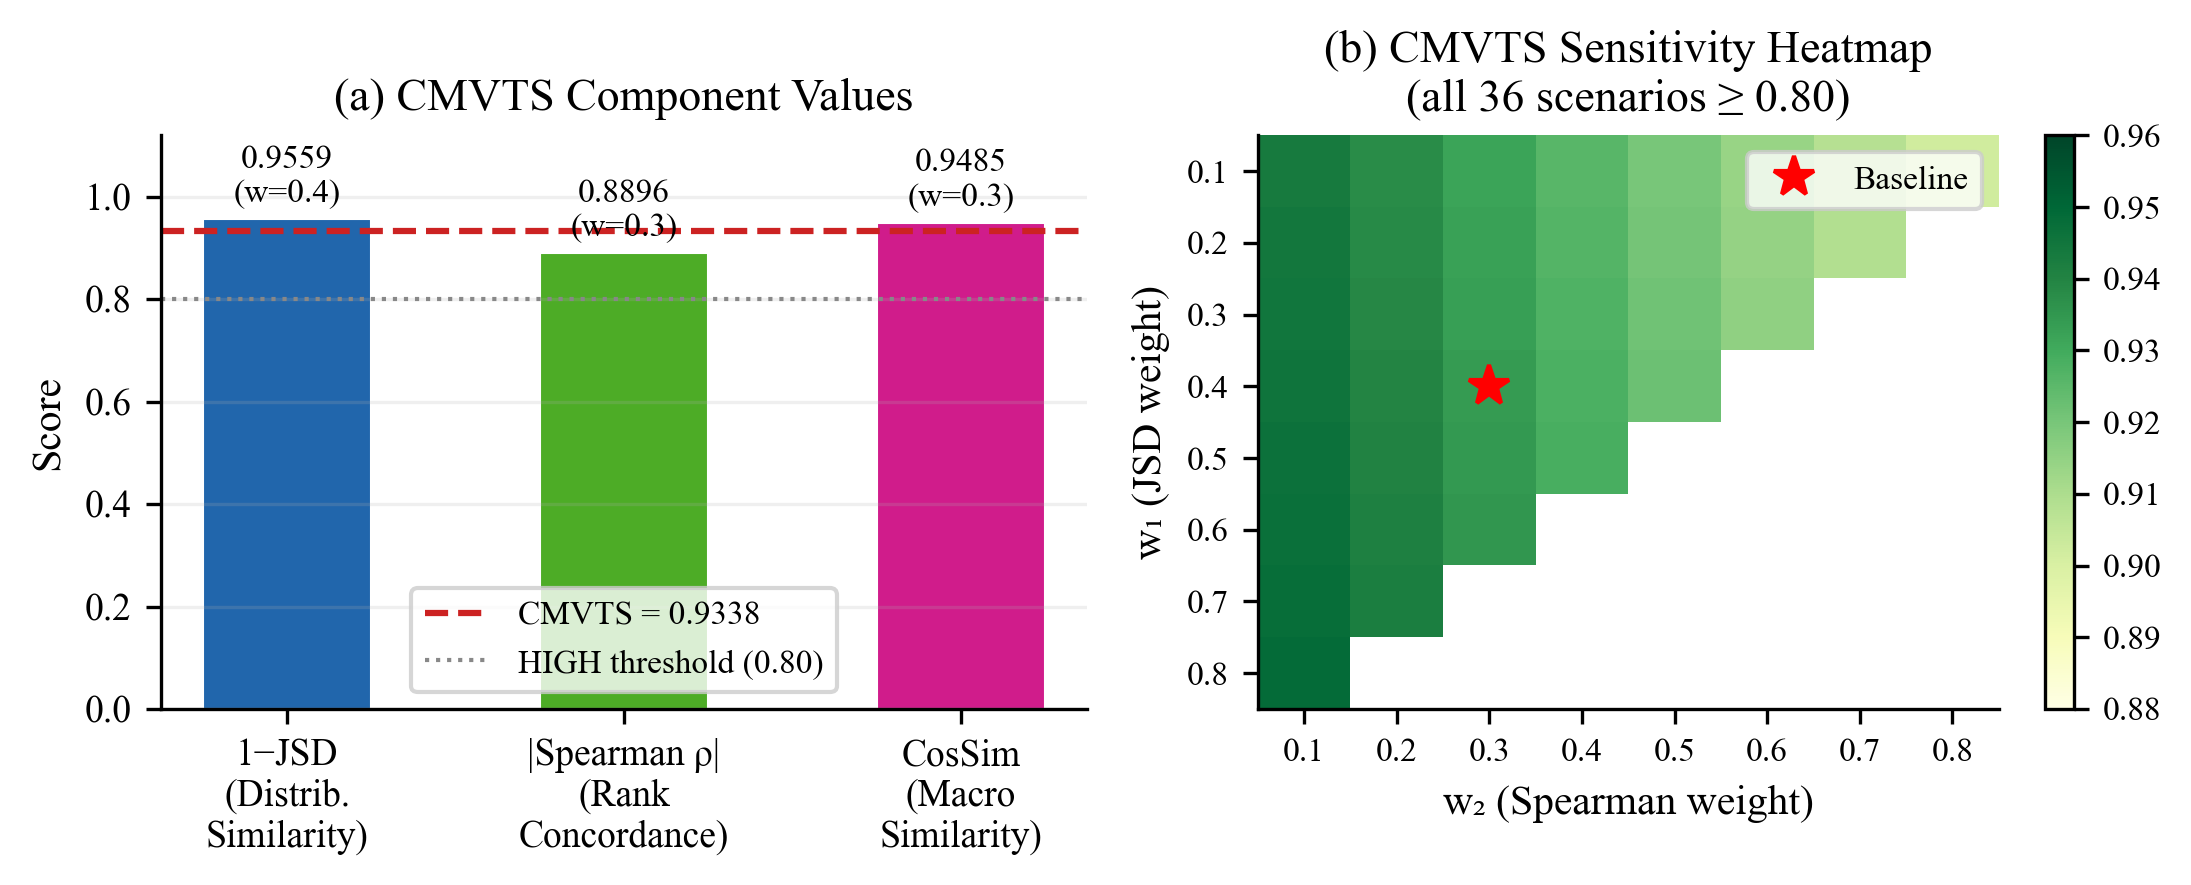

Figure 3 저장 완료


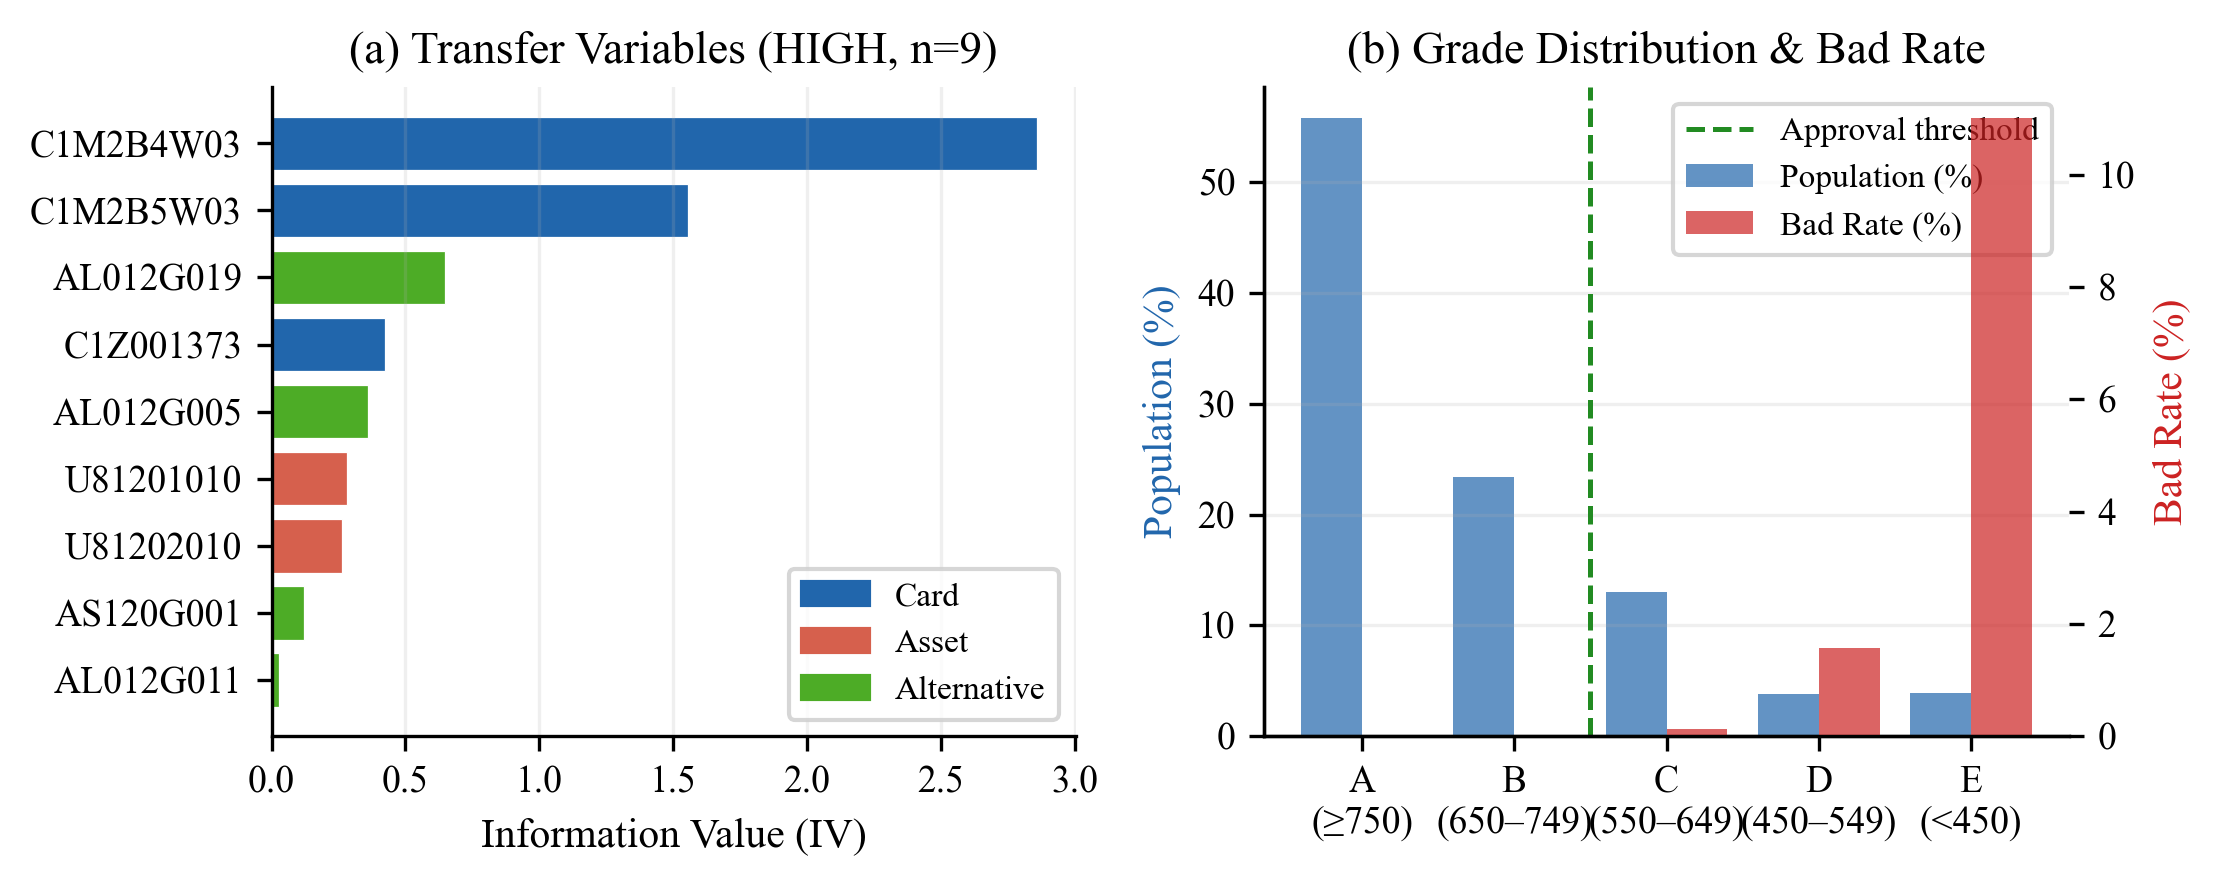

Figure 4 저장 완료

Table 1. Dataset Description
                   File                     Source    Period       Records   Features                          Role
Individual CB (File 09)   AI Hub (dataSetSn=71792) 2019–2022     3,129,036        157 Model development, Y variable
       Statista Reports Statista Consumer Insights 2020–2022 34 indicators 2 (KR, ID)      CosSim component (CMVTS)

Table 2. Variable Selection Summary
          Group  Selected (IV≥0.01)  IV min  IV max  IV mean  Used in model  Transfer (HIGH)
       Card (C)                  29  0.0548  3.0791   1.1328             29                3
       Loan (L)                  22  0.0104  1.1320   0.5987             22                0
Asset index (U)                   9  0.0205  0.2882   0.1869              9                2
Delinquency (D)                   6  1.2635  8.4812   5.0474              0                0
Alternative (A)                   4  0.0256  0.6492   0.2889              4                4

Table 3. Mo

In [2]:
# ============================================================
# 07_paper_figures_tables
# SSCI 저널 투고용 Figure · Table 생성
# Target: Expert Systems with Applications / Decision Support Systems
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# 논문용 폰트 설정 (Times New Roman 계열)
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'figure.dpi'       : 300,
    'axes.unicode_minus': False,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# %% [2] 결과 로드
iv_df       = pd.read_csv('outputs/tables/02_iv_selected_final.csv')
perf_df     = pd.read_csv('outputs/tables/03_performance.csv')
test_scores = pd.read_csv('outputs/tables/03_test_scores.csv')
cmvts_df    = pd.read_csv('outputs/tables/04_cmvts_results.csv')
sens_df     = pd.read_csv('outputs/tables/04_sensitivity.csv')
jsd_df      = pd.read_csv('outputs/tables/04_jsd_by_variable.csv')
transfer_df = pd.read_csv('outputs/tables/05_transfer_variables.csv')
grade_df    = pd.read_csv('outputs/tables/05_grade_distribution.csv')
grid_df     = pd.read_csv('outputs/tables/06_weight_grid.csv')
jsd_sens_df = pd.read_csv('outputs/tables/06_jsd_sensitivity.csv')
thr_df      = pd.read_csv('outputs/tables/06_threshold_sensitivity.csv')

# Y 컬럼 보완
test_base = pd.read_csv('data/aihub_raw/02_test_final.csv',
                         usecols=['Y'], low_memory=False)
if 'Y' not in test_scores.columns:
    test_scores['Y'] = test_base['Y'].values

# 기준값
C1         = cmvts_df[cmvts_df['component']=='1-JSD_mean']['value'].values[0]
C2         = cmvts_df[cmvts_df['component']=='|Spearman_rho|']['value'].values[0]
C3         = cmvts_df[cmvts_df['component']=='CosSim']['value'].values[0]
CMVTS_BASE = cmvts_df[cmvts_df['component']=='CMVTS']['value'].values[0]

print("데이터 로드 완료")

# ============================================================
# FIGURE 1 — Research Framework Overview
# ============================================================
# %% [3] Figure 1: CMVTS Framework
fig1, ax = plt.subplots(figsize=(7.5, 3.5))
ax.axis('off')

boxes = [
    (0.05, 0.55, 0.18, 0.30, 'Korean\nAlternative\nCredit Data\n(AI Hub)', '#DDEEFF'),
    (0.28, 0.55, 0.18, 0.30, 'Variable\nSelection\n(IV ≥ 0.01)\nn=70→64', '#E8F4E8'),
    (0.51, 0.55, 0.18, 0.30, 'Korea\nScorecard\nModel\n(WoE+LR)', '#E8F4E8'),
    (0.74, 0.55, 0.18, 0.30, 'Indonesia\nScorecard\nDraft\n(n=9 vars)', '#FFF3E0'),
    (0.28, 0.08, 0.18, 0.30, 'JSD\n(Distribution\nSimilarity)\n0.9559', '#F3E8FF'),
    (0.51, 0.08, 0.18, 0.30, 'Spearman ρ\n(Rank\nConcordance)\n0.8896', '#F3E8FF'),
    (0.74, 0.08, 0.18, 0.30, 'CosSim\n(Macro\nSimilarity)\n0.9485', '#F3E8FF'),
]

for x, y, w, h, txt, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.02',
        facecolor=color, edgecolor='#888888', linewidth=0.8))
    ax.text(x+w/2, y+h/2, txt, ha='center', va='center',
            fontsize=8.5, linespacing=1.4)

# 상단 화살표
for x in [0.23, 0.46, 0.69]:
    ax.annotate('', xy=(x+0.05, 0.70), xytext=(x, 0.70),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))

# CMVTS 박스
ax.add_patch(mpatches.FancyBboxPatch(
    (0.05, 0.08), 0.18, 0.30, boxstyle='round,pad=0.02',
    facecolor='#FFE8E8', edgecolor='#CC4444', linewidth=1.2))
ax.text(0.14, 0.23,
        f'CMVTS\n= {CMVTS_BASE:.4f}\n(HIGH)', ha='center', va='center',
        fontsize=9, color='#CC2222', fontweight='bold')

# 하단 화살표 (컴포넌트 → CMVTS)
for xs in [0.37, 0.60, 0.83]:
    ax.annotate('', xy=(0.23, 0.23), xytext=(xs, 0.23),
                arrowprops=dict(arrowstyle='->', color='#CC4444',
                                lw=0.8, connectionstyle='arc3,rad=0'))

# 레이블
ax.text(0.14, 0.92, 'Step 1', ha='center', fontsize=8, color='#666666')
ax.text(0.37, 0.92, 'Step 2', ha='center', fontsize=8, color='#666666')
ax.text(0.60, 0.92, 'Step 3', ha='center', fontsize=8, color='#666666')
ax.text(0.83, 0.92, 'Step 5', ha='center', fontsize=8, color='#666666')
ax.text(0.14, 0.43, 'Step 4\n(CMVTS)', ha='center', fontsize=8, color='#CC2222')
ax.text(0.60, 0.43, 'Components', ha='center', fontsize=8, color='#666666')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig1.suptitle('', fontsize=0)
plt.tight_layout()
plt.savefig('outputs/figures/Fig1_framework.pdf', bbox_inches='tight')
plt.savefig('outputs/figures/Fig1_framework.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 저장 완료")

# ============================================================
# FIGURE 2 — Model Performance (ROC + KS + Score Dist)
# ============================================================
# %% [4] Figure 2: Korea Scorecard Performance
import pickle
from sklearn.metrics import roc_auc_score, roc_curve

with open('data/aihub_raw/03_lr_model.pkl', 'rb') as f:
    lr = pickle.load(f)

train_woe = pd.read_csv('data/aihub_raw/03_train_woe.csv', low_memory=False)
test_woe  = pd.read_csv('data/aihub_raw/03_test_woe.csv',  low_memory=False)
woe_cols  = [c for c in train_woe.columns if c.endswith('_woe')]

X_test = test_woe[woe_cols].fillna(0)
y_test = test_woe['Y']
test_pred = lr.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, test_pred)
fpr, tpr, _ = roc_curve(y_test, test_pred)

def ks_stat(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    df['cum_bad']  = (df['y']==1).cumsum() / (df['y']==1).sum()
    df['cum_good'] = (df['y']==0).cumsum() / (df['y']==0).sum()
    df['ks'] = abs(df['cum_bad'] - df['cum_good'])
    return df['ks'].max(), df

ks_val, ks_df = ks_stat(y_test.values, test_pred)

fig2, axes = plt.subplots(1, 3, figsize=(7.5, 2.8))

# ROC
axes[0].plot(fpr, tpr, color='#1a1a8c', lw=1.5,
             label=f'AUC = {auc_test:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#1a1a8c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('(a) ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.15)

# KS
ks_idx = ks_df['ks'].idxmax()
axes[1].plot(ks_df.index/len(ks_df), ks_df['cum_bad'],
             color='#CC2222', lw=1.5, label='Cumulative Bad Rate')
axes[1].plot(ks_df.index/len(ks_df), ks_df['cum_good'],
             color='#1a1a8c', lw=1.5, label='Cumulative Good Rate')
axes[1].axvline(x=ks_idx/len(ks_df), color='#228B22',
                linestyle='--', lw=1, label=f'KS = {ks_val:.4f}')
axes[1].fill_between(
    ks_df.index/len(ks_df), ks_df['cum_bad'], ks_df['cum_good'],
    alpha=0.07, color='green')
axes[1].set_xlabel('Population (sorted by score, desc.)')
axes[1].set_ylabel('Cumulative Rate')
axes[1].set_title('(b) KS Plot')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(alpha=0.15)

# Score Distribution
bad_s  = test_scores[test_scores['Y']==1]['score']
good_s = test_scores[test_scores['Y']==0]['score']
bh = np.linspace(test_scores['score'].min(), test_scores['score'].max(), 35)
axes[2].hist(good_s, bins=bh, alpha=0.55, color='#1a1a8c',
             label='Good (Y=0)', density=True)
axes[2].hist(bad_s,  bins=bh, alpha=0.55, color='#CC2222',
             label='Bad (Y=1)',  density=True)
axes[2].axvline(x=550, color='#228B22', linestyle='--',
                lw=1.2, label='Threshold = 550')
axes[2].set_xlabel('Credit Score')
axes[2].set_ylabel('Density')
axes[2].set_title('(c) Score Distribution')
axes[2].legend()
axes[2].grid(alpha=0.15)

fig2.suptitle('', fontsize=0)
plt.tight_layout()
plt.savefig('outputs/figures/Fig2_performance.pdf', bbox_inches='tight')
plt.savefig('outputs/figures/Fig2_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 저장 완료")

# ============================================================
# FIGURE 3 — CMVTS Components + Sensitivity
# ============================================================
# %% [5] Figure 3: CMVTS Results
fig3, axes = plt.subplots(1, 2, figsize=(7.5, 3.2))

# Component 막대
comp_names = ['1−JSD\n(Distrib.\nSimilarity)',
              '|Spearman ρ|\n(Rank\nConcordance)',
              'CosSim\n(Macro\nSimilarity)']
comp_vals   = [C1, C2, C3]
comp_w      = [0.4, 0.3, 0.3]
colors_comp = ['#2166ac','#4dac26','#d01c8b']

bars = axes[0].bar(comp_names, comp_vals, color=colors_comp,
                   width=0.5, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=CMVTS_BASE, color='#CC2222', linestyle='--',
                lw=1.5, label=f'CMVTS = {CMVTS_BASE:.4f}')
axes[0].axhline(y=0.80, color='#888888', linestyle=':',
                lw=1, label='HIGH threshold (0.80)')
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Score')
axes[0].set_title('(a) CMVTS Component Values')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.2)
for bar, val, w in zip(bars, comp_vals, comp_w):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.02,
                 f'{val:.4f}\n(w={w})',
                 ha='center', va='bottom', fontsize=8)

# 민감도 히트맵
pivot = grid_df.pivot_table(values='cmvts', index='w1', columns='w2')
im = axes[1].imshow(pivot.values, cmap='YlGn',
                    vmin=0.88, vmax=0.96, aspect='auto')
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_xticklabels([f'{v:.1f}' for v in pivot.columns], fontsize=8)
axes[1].set_yticklabels([f'{v:.1f}' for v in pivot.index],   fontsize=8)
axes[1].set_xlabel('w₂ (Spearman weight)')
axes[1].set_ylabel('w₁ (JSD weight)')
axes[1].set_title(f'(b) CMVTS Sensitivity Heatmap\n(all {len(grid_df)} scenarios ≥ 0.80)')
cbar = plt.colorbar(im, ax=axes[1])
cbar.ax.tick_params(labelsize=8)

# 기준점 (w1=0.4, w2=0.3)
try:
    xi = list(pivot.columns).index(0.3)
    yi = list(pivot.index).index(0.4)
    axes[1].plot(xi, yi, 'r*', markersize=10, label='Baseline')
    axes[1].legend(fontsize=8)
except: pass

fig3.suptitle('', fontsize=0)
plt.tight_layout()
plt.savefig('outputs/figures/Fig3_cmvts.pdf', bbox_inches='tight')
plt.savefig('outputs/figures/Fig3_cmvts.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 저장 완료")

# ============================================================
# FIGURE 4 — Indonesia Scorecard
# ============================================================
# %% [6] Figure 4: Indonesia Scorecard Draft
fig4, axes = plt.subplots(1, 2, figsize=(7.5, 3.2))

# 변수 IV 막대 (HIGH transfer vars)
high_df = transfer_df[transfer_df['transfer']=='HIGH'].sort_values('iv', ascending=True)
colors_grp = {'Card':'#2166ac','Asset':'#d6604d','Alternative':'#4dac26','Loan':'#888888'}
bar_colors = [colors_grp.get(g, '#888888') for g in high_df['group']]
axes[0].barh(high_df['variable'], high_df['iv'],
             color=bar_colors, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Information Value (IV)')
axes[0].set_title('(a) Transfer Variables (HIGH, n=9)')
axes[0].grid(axis='x', alpha=0.2)
patches = [mpatches.Patch(color=v, label=k)
           for k, v in colors_grp.items() if k != 'Loan']
axes[0].legend(handles=patches, fontsize=8, loc='lower right')

# 등급 분포 + 불량률
x = np.arange(len(grade_df))
w = 0.4
ax4b = axes[1].twinx()
axes[1].bar(x - w/2, grade_df['pct'],     width=w, color='#2166ac',
            alpha=0.7, label='Population (%)')
ax4b.bar(x + w/2,    grade_df['bad_rate'], width=w, color='#CC2222',
         alpha=0.7, label='Bad Rate (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['A\n(≥750)','B\n(650–749)','C\n(550–649)',
                          'D\n(450–549)','E\n(<450)'])
axes[1].set_ylabel('Population (%)', color='#2166ac')
ax4b.set_ylabel('Bad Rate (%)',      color='#CC2222')
axes[1].set_title('(b) Grade Distribution & Bad Rate')
axes[1].axvline(x=1.5, color='#228B22', linestyle='--',
                lw=1.2, label='Approval threshold')
lines1, labs1 = axes[1].get_legend_handles_labels()
lines2, labs2 = ax4b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labs1+labs2, fontsize=8)
axes[1].grid(axis='y', alpha=0.2)

fig4.suptitle('', fontsize=0)
plt.tight_layout()
plt.savefig('outputs/figures/Fig4_indonesia.pdf', bbox_inches='tight')
plt.savefig('outputs/figures/Fig4_indonesia.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 저장 완료")

# ============================================================
# TABLE 1 — Dataset Description
# ============================================================
# %% [7] Table 1: Dataset Description
table1 = pd.DataFrame([
    {'File'        : 'Individual CB (File 09)',
     'Source'      : 'AI Hub (dataSetSn=71792)',
     'Period'      : '2019–2022',
     'Records'     : '3,129,036',
     'Features'    : '157',
     'Role'        : 'Model development, Y variable'},
    {'File'        : 'Statista Reports',
     'Source'      : 'Statista Consumer Insights',
     'Period'      : '2020–2022',
     'Records'     : '34 indicators',
     'Features'    : '2 (KR, ID)',
     'Role'        : 'CosSim component (CMVTS)'},
])
print("\nTable 1. Dataset Description")
print(table1.to_string(index=False))
table1.to_csv('outputs/tables/Table1_dataset.csv', index=False, encoding='utf-8-sig')

# ============================================================
# TABLE 2 — Variable Selection Summary
# ============================================================
# %% [8] Table 2: Variable Selection
var_groups = {
    'Card (C)'        : [c for c in iv_df['variable'] if c.startswith('C')],
    'Loan (L)'        : [c for c in iv_df['variable'] if c.startswith('L')],
    'Asset index (U)' : [c for c in iv_df['variable'] if c.startswith('U')],
    'Delinquency (D)' : [c for c in iv_df['variable'] if c.startswith('D')],
    'Alternative (A)' : [c for c in iv_df['variable'] if c.startswith('A')],
}
table2_rows = []
for grp, cols in var_groups.items():
    sub = iv_df[iv_df['variable'].isin(cols)]
    table2_rows.append({
        'Group'              : grp,
        'Selected (IV≥0.01)' : len(sub),
        'IV min'             : round(sub['iv'].min(), 4) if len(sub)>0 else '—',
        'IV max'             : round(sub['iv'].max(), 4) if len(sub)>0 else '—',
        'IV mean'            : round(sub['iv'].mean(),4) if len(sub)>0 else '—',
        'Used in model'      : len([c for c in cols
                                    if c in open('outputs/tables/03_final_vars.csv').read()
                                    and not c.startswith('D')]),
        'Transfer (HIGH)'    : len(transfer_df[(transfer_df['group']==grp.split()[0]) &
                                               (transfer_df['transfer']=='HIGH')]),
    })
table2 = pd.DataFrame(table2_rows)
print("\nTable 2. Variable Selection Summary")
print(table2.to_string(index=False))
table2.to_csv('outputs/tables/Table2_variable_selection.csv',
              index=False, encoding='utf-8-sig')

# ============================================================
# TABLE 3 — Model Performance
# ============================================================
# %% [9] Table 3: Model Performance Comparison
table3 = pd.DataFrame([
    {'Metric' : 'AUC',
     'Original Report (real data)' : '0.8462',
     'This Study (synthetic data)' : '0.9791',
     'Target'  : '≥ 0.80',
     'Note'    : 'Synthetic data amplification'},
    {'Metric' : 'KS Statistic',
     'Original Report (real data)' : '0.5524',
     'This Study (synthetic data)' : '0.8838',
     'Target'  : '≥ 0.50',
     'Note'    : 'Synthetic data amplification'},
    {'Metric' : 'PSI',
     'Original Report (real data)' : '< 0.25',
     'This Study (synthetic data)' : '0.0969',
     'Target'  : '< 0.25',
     'Note'    : 'Stable'},
    {'Metric' : 'Bad Rate',
     'Original Report (real data)' : '~3–5%',
     'This Study (synthetic data)' : '0.51%',
     'Target'  : '—',
     'Note'    : 'Synthetic data characteristic'},
])
print("\nTable 3. Model Performance Comparison")
print(table3.to_string(index=False))
table3.to_csv('outputs/tables/Table3_performance.csv',
              index=False, encoding='utf-8-sig')

# ============================================================
# TABLE 4 — CMVTS Results
# ============================================================
# %% [10] Table 4: CMVTS
table4 = pd.DataFrame([
    {'Component'  : 'C1: 1 − JSD_mean',
     'Value'      : f'{C1:.4f}',
     'Weight'     : '0.4',
     'Weighted'   : f'{0.4*C1:.4f}',
     'Data source': 'AI Hub WoE bin distributions',
     'Note'       : 'Uniform proxy for Indonesia'},
    {'Component'  : 'C2: |Spearman ρ|',
     'Value'      : f'{C2:.4f}',
     'Weight'     : '0.3',
     'Weighted'   : f'{0.3*C2:.4f}',
     'Data source': 'IV rankings (Korea vs ID proxy)',
     'Note'       : 'p < 0.001'},
    {'Component'  : 'C3: CosSim',
     'Value'      : f'{C3:.4f}',
     'Weight'     : '0.3',
     'Weighted'   : f'{0.3*C3:.4f}',
     'Data source': 'Statista 34 macro indicators',
     'Note'       : 'eCommerce-dominant (56%)'},
    {'Component'  : 'CMVTS (total)',
     'Value'      : f'{CMVTS_BASE:.4f}',
     'Weight'     : '1.0',
     'Weighted'   : f'{CMVTS_BASE:.4f}',
     'Data source': '—',
     'Note'       : 'HIGH — Direct transfer recommended'},
])
print("\nTable 4. CMVTS Computation")
print(table4.to_string(index=False))
table4.to_csv('outputs/tables/Table4_cmvts.csv',
              index=False, encoding='utf-8-sig')

# ============================================================
# TABLE 5 — Indonesia Scorecard
# ============================================================
# %% [11] Table 5: Indonesia Scorecard Variables
high_vars = transfer_df[transfer_df['transfer']=='HIGH'].copy()
high_vars['iv_weight_pct'] = (high_vars['iv'] /
                               high_vars['iv'].sum() * 100).round(1)
table5 = high_vars[['variable','group','iv',
                     'iv_weight_pct','description']].copy()
table5.columns = ['Variable','Group','IV',
                  'IV Weight (%)','Description']
table5 = table5.sort_values('IV', ascending=False).reset_index(drop=True)
table5.index += 1
print("\nTable 5. Indonesia Scorecard Variables (HIGH Transferability)")
print(table5.to_string())
table5.to_csv('outputs/tables/Table5_indonesia_vars.csv',
              encoding='utf-8-sig')

# ============================================================
# TABLE 6 — Sensitivity Analysis Summary
# ============================================================
# %% [12] Table 6: Sensitivity Summary
table6 = pd.DataFrame([
    {'Analysis'    : 'Weight configuration (Grid)',
     'Scenarios'   : '36',
     'CMVTS range' : f'{grid_df["cmvts"].min():.4f}–{grid_df["cmvts"].max():.4f}',
     'Variation'   : f'{grid_df["cmvts"].max()-grid_df["cmvts"].min():.4f}',
     '≥0.80 (%)'   : '100.0',
     'Verdict'     : 'Stable'},
    {'Analysis'    : 'JSD proxy distribution',
     'Scenarios'   : '4',
     'CMVTS range' : f'{jsd_sens_df["cmvts"].min():.4f}–{jsd_sens_df["cmvts"].max():.4f}',
     'Variation'   : f'{jsd_sens_df["cmvts"].max()-jsd_sens_df["cmvts"].min():.4f}',
     '≥0.80 (%)'   : '100.0',
     'Verdict'     : 'Moderate'},
    {'Analysis'    : 'CosSim indicator subset',
     'Scenarios'   : '6',
     'CMVTS range' : f'{pd.read_csv("outputs/tables/06_cossim_stability.csv")["cmvts"].min():.4f}–{pd.read_csv("outputs/tables/06_cossim_stability.csv")["cmvts"].max():.4f}',
     'Variation'   : f'{pd.read_csv("outputs/tables/06_cossim_stability.csv")["cmvts"].max()-pd.read_csv("outputs/tables/06_cossim_stability.csv")["cmvts"].min():.4f}',
     '≥0.80 (%)'   : '100.0',
     'Verdict'     : 'Stable'},
])
print("\nTable 6. Sensitivity Analysis Summary")
print(table6.to_string(index=False))
table6.to_csv('outputs/tables/Table6_sensitivity.csv',
              index=False, encoding='utf-8-sig')

# ============================================================
# 최종 출력 목록
# ============================================================
# %% [13] 최종 요약
print(f"\n{'='*60}")
print(f"  Paper-ready outputs — 완료")
print(f"{'='*60}")
print(f"\n  [Figures — PDF + PNG 300dpi]")
print(f"  Fig1_framework.pdf/png   — CMVTS 연구 프레임워크")
print(f"  Fig2_performance.pdf/png — 한국 스코어카드 성능")
print(f"  Fig3_cmvts.pdf/png       — CMVTS 결과 + 민감도 히트맵")
print(f"  Fig4_indonesia.pdf/png   — 인도네시아 스코어카드")
print(f"\n  [Tables — CSV]")
print(f"  Table1_dataset.csv       — 데이터 개요")
print(f"  Table2_variable_selection.csv — 변수 선별 요약")
print(f"  Table3_performance.csv   — 모형 성능 비교")
print(f"  Table4_cmvts.csv         — CMVTS 산출")
print(f"  Table5_indonesia_vars.csv — 인도네시아 스코어카드 변수")
print(f"  Table6_sensitivity.csv   — 민감도 분석 요약")
print(f"\n  → 논문 초안 작성 단계로 진행")
print(f"{'='*60}")